In [122]:
import os

import pandas as pd
import plotly.express as px
import numpy as np
from dotenv import load_dotenv
from prometheus_api_client import PrometheusConnect
from prometheus_api_client.metric_range_df import MetricRangeDataFrame
from ast import literal_eval
from typing import Dict, Mapping, Iterable, Union, Optional, Any
from collections import defaultdict

from script.metrics import export_gpu_memory_metrics, adjust_columns_get_records, export_cpu_memory_metrics
from script.wasteGPU import jobids_SM_active_below_5, classify_jobs_mig
from script.code import _to_list_safe, _append_unique, add_code_for_jobs
from script.wasteTime import get_a100_jobs_over_600s, jobids_with_trailing_idle, _to_datetime_from_excel, jobids_under_10_minutes
from script.graphiques import build_levelfs_with_jobs_chart, plot_job_durations_by_start, plot_completed_jobs_max_gpu_memory, plot_job_duration_by_codes_pages
from script.rapport import build_jobs_report_doc


load_dotenv()
auth_token = os.getenv("AUTH_INFO")

from sqlalchemy.orm import (
    sessionmaker,
)
from dantdb import (
    start_db_engine,
    get_binned,
    get_records,
    get_sshare,
)

cfg = {
    'user': 'guest',
    'database': 'dant',
    'host': 'localhost',
    'port': 5432,
}
engine = start_db_engine(cfg)
Session = sessionmaker(engine)

ImportError: cannot import name 'export_cpu_memory_metrics' from 'script.metrics' (/home/helene/waste/minimal-dantdb/New_waste/script/metrics.py)

In [2]:
# Query and time range parameters
account_query = "def-jfaure_gpu"  # e.g. [def,rrg,rpp]-<project>_[cpu,gpu]
system = "narval"  # Cluster name

d_from = pd.Timestamp("2025-07-21T00:00:00Z")
d_to   = pd.Timestamp("2025-09-04T00:00:00Z")
step = "10m"  # Resolution (bin size); increase if query range grows

In [3]:
prom = PrometheusConnect(
    url="https://thanos.dant.computecanada.ca",
    headers={"Authorization": f"Basic {auth_token}"},
)
prom_filter = f"cluster='{system}'"

On lance le script **export_gpu_memory_metrics** pour avoir les métriques GPU **utilisées**: GPU usage et Mémoire GPU. **Note:** les tâches qui durent moins de 10 minutes ne sont pas compilées.

In [4]:
gpu_metric = export_gpu_memory_metrics(prom=prom, account_query=account_query, prom_filter=prom_filter, d_from=d_from, d_to=d_to, step=step)
gpu_metric
#gpu_metric.to_excel("gpu_metric-test-code.xlsx", index=False)

# Puisque les données de juillet ne sont plus disponibles je les ai ajouté à la main dans gpu_metrics-def-jfaure_gpu-filled-4.xlsx.
gpu_metric = pd.read_excel("gpu_metrics-def-jfaure_gpu-filled-4.xlsx", sheet_name="Sheet1")
gpu_metric

Wrote → gpu_metrics.xlsx


,slurmjobid,instance,timestamp_excel,gpu_util,memory_util
0,46652234,NaN,2025-07-21 08:30:00,0.0,0.444596
1,46652234,NaN,2025-07-21 08:40:00,0.0,0.444596
2,46652234,NaN,2025-07-21 08:50:00,0.0,0.444596
3,46652234,NaN,2025-07-21 09:00:00,0.0,0.444596
4,46652234,NaN,2025-07-21 09:10:00,0.0,0.444596
...,...,...,...,...,...
155,48895891,ng30904:9798,2025-08-27 14:10:00,0.0,24.226562
156,48895891,ng30904:9798,2025-08-27 14:20:00,0.0,24.227051
157,48901596,ng30709:9798,2025-08-27 16:20:00,0.0,0.000000
158,48921663,ng30904:9798,2025-08-27 23:50:00,0.0,0.000000


On roule les scripts **get_binned** et **get_record** pour les ressources **demandées** (CPU, GPU, mémoire etc.)

bin = interval de temps. On peut choisir 1h ou 1D. Si on met 1D, on va avoir en output toutes les tâches lancées pour chaque journée.

**get_binned:**

In [5]:
with Session() as session:
    binned_frame = get_binned(
        session,
        system=system,
        start=d_from,
        account=account_query,
        end=d_to,
        mode='usage',
        bin_size='1D',
        state=None,
        cols=['jobs', 'metrics', 'Cluster']
    )

#binned_frame.to_excel("binned_frame.xlsx", index=False)
binned_frame

jobs  \
scheduler state     Cluster date       Account        User                                                         
slurm     completed narval  2025-07-21 def-jfaure_gpu alexsal       [350709927, 350713416, 350713437, 350715867]   
                            2025-07-22 def-jfaure_gpu alexsal                             [350737331, 350863704]   
                            2025-07-26 def-jfaure_gpu alexsal                                        [351478686]   
                            2025-07-27 def-jfaure_gpu alexsal                             [351623048, 351623666]   
                            2025-07-28 def-jfaure_gpu alexsal  [351676490, 353590772, 353592801, 353592843, 3...   
                            2025-07-29 def-jfaure_gpu alexsal                  [353621771, 353845259, 353849484]   
                            2025-07-30 def-jfaure_gpu alexsal  [354093415, 354097691, 354102264, 354116665, 3...   
                            2025-08-01 def-jfaure_gpu alexsal                  [354343314, 354893764, 354895105]   
                            2025-08-03 def-jfaure_gpu alexsal  [355016059, 355016106, 355018210, 355018425, 3...   
                            2025-08-04 def-jfaure_gpu alexsal                  [355068590, 355072309, 355073187]   
                            2025-08-05 def-jfaure_gpu alexsal                                        [355371109]   
                            2025-08-06 def-jfaure_gpu alexsal  [355382083, 355386286, 355387404, 355637873, 3...   
                            2025-08-16 def-jfaure_gpu alexsal       [358588796, 358589200, 358589478, 358590925]   
                            2025-08-18 def-jfaure_gpu alexsal                             [358765782, 358769840]   
                            2025-08-21 def-jfaure_gpu alexsal                                        [360632077]   
                            2025-08-22 def-jfaure_gpu alexsal       [360882741, 360887462, 360890065, 360894525]   
                            2025-08-23 def-jfaure_gpu alexsal  [361156449, 361157780, 361158388, 361158989, 3...   
                            2025-08-24 def-jfaure_gpu alexsal                             [361212658, 361213568]   
                            2025-08-26 def-jfaure_gpu alexsal  [361756272, 361756786, 361756924, 361940471, 3...   
                            2025-08-27 def-jfaure_gpu alexsal       [361965200, 362158915, 362164620, 362184681]   
                            2025-08-28 def-jfaure_gpu alexsal                                        [362464710]   

                                                                                                         metrics  
scheduler state     Cluster date       Account        User                                                        
slurm     completed narval  2025-07-21 def-jfaure_gpu alexsal  {'cpu': 4568, 'gpu': 4568, 'mem': 146176.0, 'r...  
                            2025-07-22 def-jfaure_gpu alexsal  {'cpu': 7226, 'gpu': 7226, 'mem': 231232.0, 'r...  
                            2025-07-26 def-jfaure_gpu alexsal  {'cpu': 893, 'gpu': 893, 'mem': 28576.0, 'rgu'...  
                            2025-07-27 def-jfaure_gpu alexsal  {'cpu': 1009, 'gpu': 1009, 'mem': 32288.0, 'rg...  
                            2025-07-28 def-jfaure_gpu alexsal  {'cpu': 11744, 'gpu': 11744, 'mem': 1106912.0,...  
                            2025-07-29 def-jfaure_gpu alexsal  {'cpu': 9947, 'gpu': 9947, 'mem': 1193640.0, '...  
                            2025-07-30 def-jfaure_gpu alexsal  {'cpu': 21814, 'gpu': 21814, 'mem': 2617680.0,...  
                            2025-08-01 def-jfaure_gpu alexsal  {'cpu': 4, 'gpu': 4, 'mem': 480.0, 'rgu': 16.0...  
                            2025-08-03 def-jfaure_gpu alexsal  {'cpu': 8752, 'gpu': 8752, 'mem': 1050240.0, '...  
                            2025-08-04 def-jfaure_gpu alexsal  {'cpu': 2951, 'gpu': 2951, 'mem': 236080.0, 'r...  
                            2025-08-05 def-jfaure_gpu alexs

On roule **get_records:**

Retrieve SLURM job records from the database based on time range and other filters.

On utilise la liste des job (jobID) de get_binned.

db_id : int | list[int] | None, optional

    Filter by the database primary key 'id'. A temporary table is used for filtering.

In [6]:
cols = ['JobID', 'Account', 'User', 'Start', 'End', 'Submit', 'Eligible', 'NCPUS', 'AllocNodes',
        'ReqCPUS' ,'ReqMem', 'Timelimit', 'Elapsed', 'ReqTRES', 'AllocTRES', 'Priority', 'Partition', 'State', 'NodeList', 'Cluster']

with Session() as session:
    jobs_frame = get_records(
        session,
        db_id=set().union(*binned_frame['jobs']),
        cols = cols,
    )
jobs_frame

,JobID,Account,User,Start,End,Submit,Eligible,NCPUS,AllocNodes,ReqCPUS,ReqMem,Timelimit,Elapsed,ReqTRES,AllocTRES,Priority,Partition,State,NodeList,Cluster
id,,,,,,,,,,,,,,,,,,,,
353592843,47058270,def-jfaure_gpu,alexsal,2025-07-28 15:45:16,2025-07-28 16:08:50,2025-07-28 15:44:51,2025-07-28 15:44:51,1,1,1,32G,240,1414,"billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...","billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...",2387633,gpubase_bygpu_b2,CANCELLED by 3129286,ng10301,narval
353845259,47116188,def-jfaure_gpu,alexsal,2025-07-29 15:58:41,2025-07-29 16:15:29,2025-07-29 15:21:10,2025-07-29 15:21:10,1,1,1,120G,240,1008,"billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...","billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...",1168776,gpubase_bygpu_b2,COMPLETED,ng31203,narval
355387404,47513171,def-jfaure_gpu,alexsal,2025-08-06 03:19:20,2025-08-06 03:35:11,2025-08-06 02:58:24,2025-08-06 02:58:24,1,1,1,25G,25,951,"billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...","billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...",1289902,gpubase_bygpu_b1,COMPLETED,ng10607,narval
354097691,47177031,def-jfaure_gpu,alexsal,2025-07-30 14:23:21,2025-07-30 14:27:36,2025-07-30 14:19:10,2025-07-30 14:19:10,1,1,1,120G,240,255,"billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...","billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...",2326920,gpubase_bygpu_b2,COMPLETED,ng10608,narval
358589478,48278689,def-jfaure_gpu,alexsal,2025-08-16 17:12:03,2025-08-16 17:32:29,2025-08-16 16:58:11,2025-08-16 16:58:11,1,1,1,20G,20,1226,"billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...","billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...",1439521,gpubase_bygpu_b1,TIMEOUT,ng30703,narval
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362184681,48921663,def-jfaure_gpu,alexsal,2025-08-27 23:49:13,2025-08-27 23:51:30,2025-08-27 23:15:58,2025-08-27 23:15:58,16,1,16,256G,180,137,"billing=16000,cpu=16,gres/gpu:a100=4,gres/gpu=...","billing=16000,cpu=16,gres/gpu:a100=4,gres/gpu=...",1259906,gpubase_bynode_b1,FAILED,ng30904,narval
351623666,46955543,def-jfaure_gpu,alexsal,2025-07-27 14:14:18,2025-07-27 14:31:07,2025-07-27 14:07:30,2025-07-27 14:07:30,1,1,1,32G,60,1009,"billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...","billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...",1309455,gpubase_bygpu_b1,COMPLETED,ng10610,narval
353590772,47055491,def-jfaure_gpu,alexsal,2025-07-28 15:23:51,2025-07-28 15:40:43,2025-07-28 14:50:59,2025-07-28 14:50:59,1,1,1,32G,60,1012,"billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...","billing=4000,cpu=1,gres/gpu:a100=1,gres/gpu=1,...",1271185,gpubase_bygpu_b1,COMPLETED,ng10802,narval


On roule le script **adjust_columns_get_records** pour ajuster/ajouter des colonnes dans le dataframe.

In [7]:
jobs_frame = adjust_columns_get_records(jobs_frame)
jobs_frame
#jobs_frame.to_excel("job_frame-test-code.xlsx", index=False)

,JobID,Account,User,Start,End,Submit,Eligible,NCPUS,AllocNodes,ReqCPUS,...,timelimit_hours,time_delta_hours,time_delta_norm,billing,cpu,gpu_type,gpu,memory_Gb,GPU_CPU_day,code
0,46652234,def-jfaure_gpu,alexsal,2025-07-21 08:23:50,2025-07-21 09:23:54,2025-07-21 08:23:47,2025-07-21 08:23:47,1,1,1,...,1.0,-0.001111,-0.001111,4000,1,gres/gpu:a100,1,32.0,0.166852,
1,46655723,def-jfaure_gpu,alexsal,2025-07-21 11:20:26,2025-07-21 11:20:26,2025-07-21 11:19:15,2025-07-21 11:19:15,0,0,1,...,1.0,1.000000,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,
2,46655744,def-jfaure_gpu,alexsal,2025-07-21 11:37:34,2025-07-21 11:37:34,2025-07-21 11:20:30,2025-07-21 11:20:30,0,0,1,...,1.0,1.000000,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,
3,46658174,def-jfaure_gpu,alexsal,2025-07-21 13:49:13,2025-07-21 14:05:17,2025-07-21 13:15:15,2025-07-21 13:15:15,1,1,1,...,1.0,0.732222,0.732222,4000,1,gres/gpu:a100,1,32.0,0.04463,
4,46680964,def-jfaure_gpu,alexsal,2025-07-22 00:37:28,2025-07-22 01:37:38,2025-07-21 23:35:23,2025-07-21 23:35:23,1,1,1,...,1.0,-0.002778,-0.002778,4000,1,gres/gpu:a100,1,32.0,0.16713,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,48883125,def-jfaure_gpu,alexsal,2025-08-27 02:14:24,2025-08-27 02:16:34,2025-08-27 01:31:13,2025-08-27 01:31:13,16,1,16,...,3.0,2.963889,0.987963,16000,16,gres/gpu:a100,4,256.0,0.024074,
75,48895891,def-jfaure_gpu,alexsal,2025-08-27 13:06:19,2025-08-27 14:23:04,2025-08-27 12:36:37,2025-08-27 12:36:37,16,1,16,...,3.0,1.720833,0.573611,16000,16,gres/gpu:a100,4,256.0,0.852778,
76,48901596,def-jfaure_gpu,alexsal,2025-08-27 16:19:12,2025-08-27 16:29:23,2025-08-27 15:54:39,2025-08-27 15:54:39,16,1,16,...,3.0,2.830278,0.943426,16000,16,gres/gpu:a100,4,256.0,0.113148,
77,48921663,def-jfaure_gpu,alexsal,2025-08-27 23:49:13,2025-08-27 23:51:30,2025-08-27 23:15:58,2025-08-27 23:15:58,16,1,16,...,3.0,2.961944,0.987315,16000,16,gres/gpu:a100,4,256.0,0.02537,


Pour rouler le script **get_sshare** afin d'avoir le LevelFS:

In [8]:
with Session() as session:
    sshare_frame = get_sshare(
        session,
        system=system,
        start=d_from,
        end=d_to,
        latest=False,
        cols=['Cluster', 'date', 'Account','RawShares', 'NormShares', 'RawUsage', 'NormUsage', 'LevelFS'],
        rows=['def-jfaure_gpu']
    )
# On ajoute l'index des dates en une colonne date.
sshare_frame = sshare_frame.reset_index()
sshare_frame

,date,Cluster,Account,RawShares,NormShares,RawUsage,NormUsage,LevelFS
0,2025-07-21 00:00:00,narval,def-jfaure_gpu,1,0.0,0,0.000000,inf
1,2025-07-21 00:30:00,narval,def-jfaure_gpu,1,0.0,0,0.000000,inf
2,2025-07-21 01:00:00,narval,def-jfaure_gpu,1,0.0,0,0.000000,inf
3,2025-07-21 01:30:00,narval,def-jfaure_gpu,1,0.0,0,0.000000,inf
4,2025-07-21 02:00:00,narval,def-jfaure_gpu,1,0.0,0,0.000000,inf
...,...,...,...,...,...,...,...,...
2148,2025-09-03 21:30:00,narval,def-jfaure_gpu,1,0.0,70803920,0.000001,0.008696
2149,2025-09-03 22:00:00,narval,def-jfaure_gpu,1,0.0,70658037,0.000001,0.008739
2150,2025-09-03 22:30:00,narval,def-jfaure_gpu,1,0.0,70512455,0.000001,0.008757
2151,2025-09-03 23:00:00,narval,def-jfaure_gpu,1,0.0,70367173,0.000001,0.008677


In [9]:
#sshare_frame.to_excel("sshare_frame.xlsx", index=False)

On roule le script **jobids_SM_active_below_5** pour identifier les tâches dont le SM active est plus petit que 5 pour la durée totale de la tâche.

Input = **gpu_metric** dataframe, les données utilisées.

In [10]:
jobids_dict_SM_active_below_5 = jobids_SM_active_below_5(gpu_metric)
jobids_dict_SM_active_below_5

{46652234: 5,
 46658174: 5,
 46680964: 5,
 46696353: 5,
 46883525: 5,
 46955543: 5,
 47055491: 5,
 47058270: 5,
 47088663: 5,
 47116188: 5,
 47181616: 5,
 47196077: 5,
 47202040: 5,
 47389641: 5,
 47389688: 5,
 47391792: 5,
 47391997: 5,
 47392676: 5,
 47392927: 5,
 47394251: 5,
 47394713: 5,
 47395882: 5,
 47442390: 5,
 47446201: 5,
 47447141: 5,
 47507849: 5,
 47512053: 5,
 47513171: 5,
 47556549: 5,
 47559202: 5,
 47559803: 5,
 48278411: 5,
 48278689: 5,
 48280138: 5,
 48335101: 5,
 48517609: 5,
 48639969: 5,
 48895891: 5,
 48901596: 5,
 48921663: 5,
 48956071: 5}

On roule le script **add_code_for_jobs** pour ajouter les codes aux jobids correspondant. 

Input = (dataframe, dictionnaire (jobid : code)

In [11]:
jobs_frame = add_code_for_jobs(jobs_frame, jobids_dict_SM_active_below_5, jobid_col="JobID")
jobs_frame
#jobs_frame.to_excel("job_frame-test-code(1).xlsx", index=False)

,JobID,Account,User,Start,End,Submit,Eligible,NCPUS,AllocNodes,ReqCPUS,...,timelimit_hours,time_delta_hours,time_delta_norm,billing,cpu,gpu_type,gpu,memory_Gb,GPU_CPU_day,code
0,46652234,def-jfaure_gpu,alexsal,2025-07-21 08:23:50,2025-07-21 09:23:54,2025-07-21 08:23:47,2025-07-21 08:23:47,1,1,1,...,1.0,-0.001111,-0.001111,4000,1,gres/gpu:a100,1,32.0,0.166852,[5]
1,46655723,def-jfaure_gpu,alexsal,2025-07-21 11:20:26,2025-07-21 11:20:26,2025-07-21 11:19:15,2025-07-21 11:19:15,0,0,1,...,1.0,1.000000,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,[]
2,46655744,def-jfaure_gpu,alexsal,2025-07-21 11:37:34,2025-07-21 11:37:34,2025-07-21 11:20:30,2025-07-21 11:20:30,0,0,1,...,1.0,1.000000,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,[]
3,46658174,def-jfaure_gpu,alexsal,2025-07-21 13:49:13,2025-07-21 14:05:17,2025-07-21 13:15:15,2025-07-21 13:15:15,1,1,1,...,1.0,0.732222,0.732222,4000,1,gres/gpu:a100,1,32.0,0.04463,[5]
4,46680964,def-jfaure_gpu,alexsal,2025-07-22 00:37:28,2025-07-22 01:37:38,2025-07-21 23:35:23,2025-07-21 23:35:23,1,1,1,...,1.0,-0.002778,-0.002778,4000,1,gres/gpu:a100,1,32.0,0.16713,[5]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,48883125,def-jfaure_gpu,alexsal,2025-08-27 02:14:24,2025-08-27 02:16:34,2025-08-27 01:31:13,2025-08-27 01:31:13,16,1,16,...,3.0,2.963889,0.987963,16000,16,gres/gpu:a100,4,256.0,0.024074,[]
75,48895891,def-jfaure_gpu,alexsal,2025-08-27 13:06:19,2025-08-27 14:23:04,2025-08-27 12:36:37,2025-08-27 12:36:37,16,1,16,...,3.0,1.720833,0.573611,16000,16,gres/gpu:a100,4,256.0,0.852778,[5]
76,48901596,def-jfaure_gpu,alexsal,2025-08-27 16:19:12,2025-08-27 16:29:23,2025-08-27 15:54:39,2025-08-27 15:54:39,16,1,16,...,3.0,2.830278,0.943426,16000,16,gres/gpu:a100,4,256.0,0.113148,[5]
77,48921663,def-jfaure_gpu,alexsal,2025-08-27 23:49:13,2025-08-27 23:51:30,2025-08-27 23:15:58,2025-08-27 23:15:58,16,1,16,...,3.0,2.961944,0.987315,16000,16,gres/gpu:a100,4,256.0,0.02537,[5]


Rouler le script **classify_jobs_mig** qui identifie les tâches A100 qui auraient pu rouler avec un MIG. Le input est le dataframe ressources utilisées, soit le output de **export_gpu_memory_metrics** : gpu_metric

usage: classify_jobs_mig(df_gpu: pd.DataFrame, jobids: list[int]) -> dict[int, int]:

On lance en premier **get_a100_jobs_over_600s** pour avoir la liste de tâches A100 de plus de 10 minutes. Le input est le dataframe ressources demandées, soit le output de **get_records** : jobs_frame.

usage: get_a100_jobs_over_600s(df: pd.DataFrame) -> list[int]:

In [12]:
joblist = get_a100_jobs_over_600s(jobs_frame)
joblist

[46652234,
 46658174,
 46680964,
 46696353,
 46883525,
 46955543,
 47055491,
 47058270,
 47066378,
 47069584,
 47088663,
 47116188,
 47120414,
 47172754,
 47181616,
 47196077,
 47202040,
 47389641,
 47389688,
 47391792,
 47391997,
 47392147,
 47392393,
 47392676,
 47392927,
 47394251,
 47394713,
 47395381,
 47395882,
 47442390,
 47446201,
 47447141,
 47496508,
 47507849,
 47512053,
 47513171,
 47556549,
 47558297,
 47559202,
 47559803,
 48278411,
 48278689,
 48280138,
 48335101,
 48339161,
 48895891,
 48901596]

In [13]:
mig_jobs_dict = classify_jobs_mig(gpu_metric, joblist)
mig_jobs_dict

{47069584: 8,
 47120414: 8,
 47392147: 8,
 47392393: 8,
 47395381: 8,
 47496508: 8,
 47558297: 8}

On roule le script **add_code_for_jobs** pour ajouter les codes aux jobids correspondant.

Input = (dataframe, dictionnaire (jobid : code)

In [14]:
jobs_frame = add_code_for_jobs(jobs_frame, mig_jobs_dict, jobid_col="JobID")
jobs_frame
#jobs_frame.to_excel("job_frame-test-MIG.xlsx", index=False)

,JobID,Account,User,Start,End,Submit,Eligible,NCPUS,AllocNodes,ReqCPUS,...,timelimit_hours,time_delta_hours,time_delta_norm,billing,cpu,gpu_type,gpu,memory_Gb,GPU_CPU_day,code
0,46652234,def-jfaure_gpu,alexsal,2025-07-21 08:23:50,2025-07-21 09:23:54,2025-07-21 08:23:47,2025-07-21 08:23:47,1,1,1,...,1.0,-0.001111,-0.001111,4000,1,gres/gpu:a100,1,32.0,0.166852,[5]
1,46655723,def-jfaure_gpu,alexsal,2025-07-21 11:20:26,2025-07-21 11:20:26,2025-07-21 11:19:15,2025-07-21 11:19:15,0,0,1,...,1.0,1.000000,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,[]
2,46655744,def-jfaure_gpu,alexsal,2025-07-21 11:37:34,2025-07-21 11:37:34,2025-07-21 11:20:30,2025-07-21 11:20:30,0,0,1,...,1.0,1.000000,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,[]
3,46658174,def-jfaure_gpu,alexsal,2025-07-21 13:49:13,2025-07-21 14:05:17,2025-07-21 13:15:15,2025-07-21 13:15:15,1,1,1,...,1.0,0.732222,0.732222,4000,1,gres/gpu:a100,1,32.0,0.04463,[5]
4,46680964,def-jfaure_gpu,alexsal,2025-07-22 00:37:28,2025-07-22 01:37:38,2025-07-21 23:35:23,2025-07-21 23:35:23,1,1,1,...,1.0,-0.002778,-0.002778,4000,1,gres/gpu:a100,1,32.0,0.16713,[5]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,48883125,def-jfaure_gpu,alexsal,2025-08-27 02:14:24,2025-08-27 02:16:34,2025-08-27 01:31:13,2025-08-27 01:31:13,16,1,16,...,3.0,2.963889,0.987963,16000,16,gres/gpu:a100,4,256.0,0.024074,[]
75,48895891,def-jfaure_gpu,alexsal,2025-08-27 13:06:19,2025-08-27 14:23:04,2025-08-27 12:36:37,2025-08-27 12:36:37,16,1,16,...,3.0,1.720833,0.573611,16000,16,gres/gpu:a100,4,256.0,0.852778,[5]
76,48901596,def-jfaure_gpu,alexsal,2025-08-27 16:19:12,2025-08-27 16:29:23,2025-08-27 15:54:39,2025-08-27 15:54:39,16,1,16,...,3.0,2.830278,0.943426,16000,16,gres/gpu:a100,4,256.0,0.113148,[5]
77,48921663,def-jfaure_gpu,alexsal,2025-08-27 23:49:13,2025-08-27 23:51:30,2025-08-27 23:15:58,2025-08-27 23:15:58,16,1,16,...,3.0,2.961944,0.987315,16000,16,gres/gpu:a100,4,256.0,0.02537,[5]


On lance le script **jobids_under_10_minutes** pour identifier les tâches qui ont roulée en bas de 10 minutes.  Le input est le dataframe ressources demandées, soit le output de get_records : jobs_frame.

usage: jobids_under_10_minutes(df: pd.DataFrame) -> Dict[int, int]:


In [15]:
job_moins_10_min = jobids_under_10_minutes(jobs_frame)
job_moins_10_min

{46655723: 1,
 46655744: 1,
 46954928: 1,
 47008374: 1,
 47058228: 1,
 47177031: 1,
 47196039: 1,
 47244672: 1,
 47267339: 1,
 47268680: 1,
 48278007: 1,
 48490463: 1,
 48517609: 1,
 48522486: 1,
 48525089: 1,
 48529549: 1,
 48582836: 1,
 48584166: 1,
 48584772: 1,
 48585376: 1,
 48588601: 1,
 48639066: 1,
 48639969: 1,
 48849837: 1,
 48850351: 1,
 48850489: 1,
 48858390: 1,
 48865862: 1,
 48872200: 1,
 48883125: 1,
 48921663: 1,
 48956071: 1}

On roule le script **add_code_for_jobs** pour ajouter les codes aux jobids correspondant.

Input = (dataframe, dictionnaire (jobid : code)

In [16]:
jobs_frame = add_code_for_jobs(jobs_frame, job_moins_10_min, jobid_col="JobID")
jobs_frame
#jobs_frame.to_excel("job_frame-test-job_moins_10_min.xlsx", index=False)

,JobID,Account,User,Start,End,Submit,Eligible,NCPUS,AllocNodes,ReqCPUS,...,timelimit_hours,time_delta_hours,time_delta_norm,billing,cpu,gpu_type,gpu,memory_Gb,GPU_CPU_day,code
0,46652234,def-jfaure_gpu,alexsal,2025-07-21 08:23:50,2025-07-21 09:23:54,2025-07-21 08:23:47,2025-07-21 08:23:47,1,1,1,...,1.0,-0.001111,-0.001111,4000,1,gres/gpu:a100,1,32.0,0.166852,[5]
1,46655723,def-jfaure_gpu,alexsal,2025-07-21 11:20:26,2025-07-21 11:20:26,2025-07-21 11:19:15,2025-07-21 11:19:15,0,0,1,...,1.0,1.000000,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,[1]
2,46655744,def-jfaure_gpu,alexsal,2025-07-21 11:37:34,2025-07-21 11:37:34,2025-07-21 11:20:30,2025-07-21 11:20:30,0,0,1,...,1.0,1.000000,1.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,[1]
3,46658174,def-jfaure_gpu,alexsal,2025-07-21 13:49:13,2025-07-21 14:05:17,2025-07-21 13:15:15,2025-07-21 13:15:15,1,1,1,...,1.0,0.732222,0.732222,4000,1,gres/gpu:a100,1,32.0,0.04463,[5]
4,46680964,def-jfaure_gpu,alexsal,2025-07-22 00:37:28,2025-07-22 01:37:38,2025-07-21 23:35:23,2025-07-21 23:35:23,1,1,1,...,1.0,-0.002778,-0.002778,4000,1,gres/gpu:a100,1,32.0,0.16713,[5]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,48883125,def-jfaure_gpu,alexsal,2025-08-27 02:14:24,2025-08-27 02:16:34,2025-08-27 01:31:13,2025-08-27 01:31:13,16,1,16,...,3.0,2.963889,0.987963,16000,16,gres/gpu:a100,4,256.0,0.024074,[1]
75,48895891,def-jfaure_gpu,alexsal,2025-08-27 13:06:19,2025-08-27 14:23:04,2025-08-27 12:36:37,2025-08-27 12:36:37,16,1,16,...,3.0,1.720833,0.573611,16000,16,gres/gpu:a100,4,256.0,0.852778,[5]
76,48901596,def-jfaure_gpu,alexsal,2025-08-27 16:19:12,2025-08-27 16:29:23,2025-08-27 15:54:39,2025-08-27 15:54:39,16,1,16,...,3.0,2.830278,0.943426,16000,16,gres/gpu:a100,4,256.0,0.113148,[5]
77,48921663,def-jfaure_gpu,alexsal,2025-08-27 23:49:13,2025-08-27 23:51:30,2025-08-27 23:15:58,2025-08-27 23:15:58,16,1,16,...,3.0,2.961944,0.987315,16000,16,gres/gpu:a100,4,256.0,0.02537,"[5, 1]"


On roule le script **jobids_with_trailing_idle** pour obtenir les tâches qui on été active puis inactive pendant un minimum de 30 minutes.

Input = **gpu_metric** dataframe, les données utilisées.


    # On pourrait changer au besoin au moins UNE mesure util > 0.... Ce n'est pas vraiment ce que l'on veut.
    Renvoie un dict {JobID: 4} pour les jobs ayant :
      - au moins UNE mesure util > 0,
      - puis, uniquement des util == 0 sur >= `minutes_idle` jusqu'à la fin du job.

In [17]:
traling_tasks = jobids_with_trailing_idle(gpu_metric)
traling_tasks

{47120414: 4, 47172754: 4}

On roule le script **add_code_for_jobs** pour ajouter les codes aux jobids correspondant.

Input = (dataframe, dictionnaire (jobid : code)

In [18]:
jobs_frame = add_code_for_jobs(jobs_frame, traling_tasks, jobid_col="JobID")
jobs_frame
jobs_frame.to_excel("job_frame-test-job_moins_10_min.xlsx", index=False)

Graphique LevelFS dans le temps avec les tâches qui ont été lancées. La taille des points correspond au montant de billing, c’est‑à‑dire la quantité de ressources demandées par la tâche.

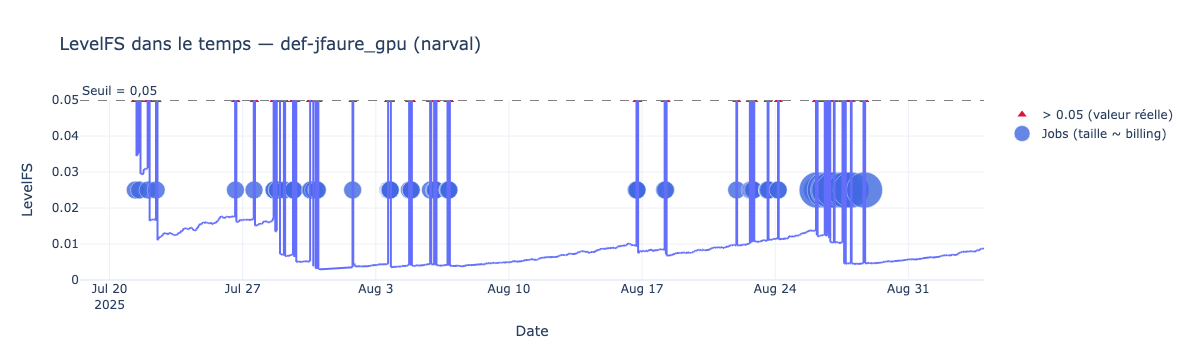

In [19]:
fig = build_levelfs_with_jobs_chart(
    sshare_frame=sshare_frame,
    jobs_frame=jobs_frame,
    account_query=account_query,
    system=system,
    y_max=0.05,              # optionnel
    max_job_marker_px=36,    # optionnel
    show=True                # optionnel
)

Graphique qui représente les tâches soumises dans le temps avec la durée en axe y. La couleur des barres correspond au montant de billing, c’est‑à‑dire la quantité de ressources demandées par la tâche.

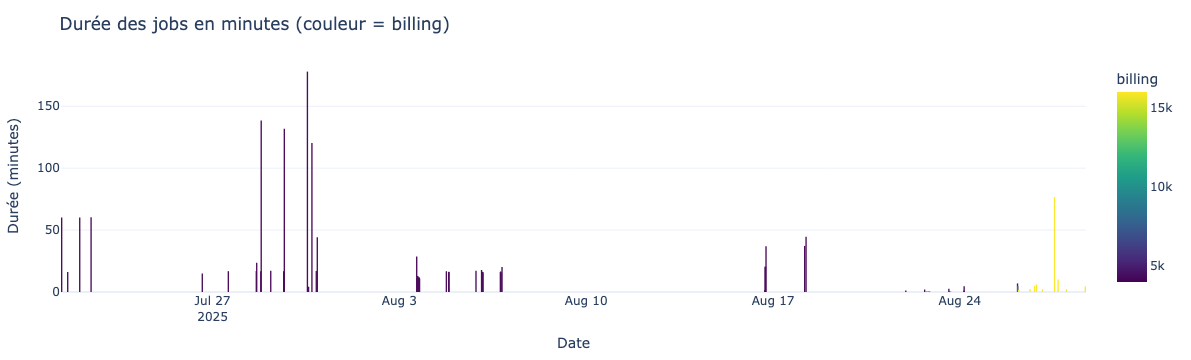

In [20]:
# jobs_df = ... # ton DataFrame (colonnes: JobID, Start, End, billing)
fig = plot_job_durations_by_start(
    df=jobs_frame,
    color_scale="Viridis",       # ou "Turbo", "Plasma", "Cividis", ...
    title="Durée des jobs en minutes (couleur = billing)",
    sort_by_start=True,
    show=True
)

Graphique qui représente le maximum de la mémoire utilisée pour les tâches qui ont un statut 'COMPLETED'.

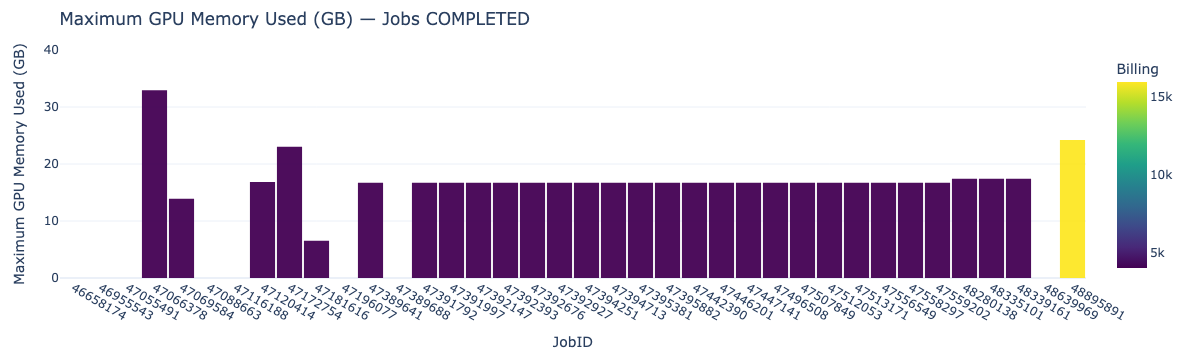

In [21]:
fig = plot_completed_jobs_max_gpu_memory(jobs_frame, gpu_metric)
fig.show()


Graphique qui représente les tâches soumises avec les codes d'erreur correspondant. La durée de la tâche est représentée dans l'axe y.

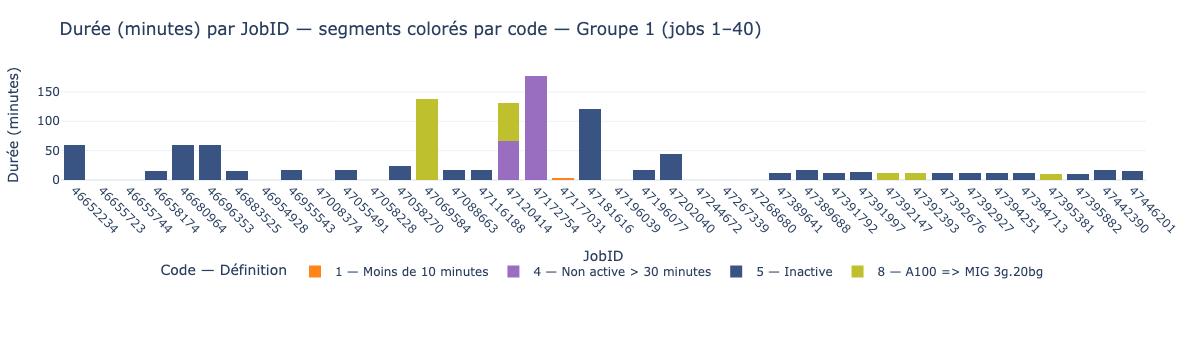

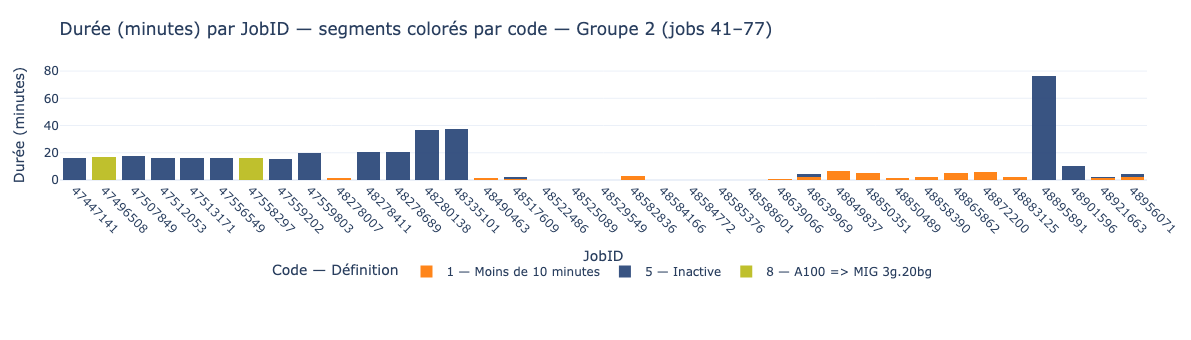

In [22]:
figs = plot_job_duration_by_codes_pages(
    jobs_frame,
    page_size=40,           
    legend_orientation="h",
    legend_y=-0.70,      # ↓ un peu plus bas si nécessaire
    bottom_margin=160    # ↑ plus d’espace pour les labels X + légende
)
for f in figs:
    f.show()

Foncgtion qui retourne un rapport sur les statistiques global et mensuel.

CODE_DEFINITIONS = {

    0:  "Correcte",
    
    1:  "Moins de 10 minutes",
    
    2:  "Interactive > 6 heures",
    
    3:  "Interactive non active pour 30 minutes",
    
    4:  "Non active > 30 minutes",
    
    5:  "Inactive",
    
    6:  "A100 => MIG 1g.5bg",
    
    7:  "A100 => MIG 2g.10bg",
    
    8:  "A100 => MIG 3g.20bg",
    
    9:  "A100 trop de mémoire CPU",
    
    10: "MIG trop de mémoire CPU",
    
    11: "Tâche MIG qui demande > 1 MIG",
    
    12: "MIG 3g.20bg => MIG 2g.10bg",
    
    13: "MIG 2g.10bg => MIG 1g.5bg",



In [23]:
df_jobs = jobs_frame
out_path = build_jobs_report_doc(df_jobs, date_col="Start", state_col="State", code_col="code",
                                 output_path="rapport_jobs.docx")
print("Fichier généré:", out_path)

Fichier généré: rapport_jobs.docx


In [25]:
gpu_metric_2 = export_gpu_memory_metrics(prom=prom, account_query=account_query, prom_filter=prom_filter, d_from=d_from, d_to=d_to, step=step)
gpu_metric_2

Wrote → gpu_metrics.xlsx


label,slurmjobid,instance,timestamp,gpu_util,memory_util,timestamp_excel
0,48278411,ng10503:9798,2025-08-16 17:00:00+00:00,0.000000,16.722656,2025-08-16 17:00:00
1,48278411,ng10503:9798,2025-08-16 17:10:00+00:00,0.000000,16.722656,2025-08-16 17:10:00
2,48278689,ng30703:9798,2025-08-16 17:20:00+00:00,0.000000,17.404297,2025-08-16 17:20:00
3,48278689,ng30703:9798,2025-08-16 17:30:00+00:00,0.000000,17.404297,2025-08-16 17:30:00
4,48280138,ng31303:9798,2025-08-16 17:50:00+00:00,0.000000,17.404297,2025-08-16 17:50:00
5,48280138,ng31303:9798,2025-08-16 18:00:00+00:00,0.000000,17.404297,2025-08-16 18:00:00
6,48280138,ng31303:9798,2025-08-16 18:10:00+00:00,0.000000,17.404297,2025-08-16 18:10:00
7,48335101,ng31006:9798,2025-08-18 04:30:00+00:00,0.000000,17.404297,2025-08-18 04:30:00
8,48335101,ng31006:9798,2025-08-18 04:40:00+00:00,0.000000,17.404297,2025-08-18 04:40:00
9,48335101,ng31006:9798,2025-08-18 04:50:00+00:00,0.000000,17.404297,2025-08-18 04:50:00


In [ ]:
test fonction pour cpu et mémoire cpu.

In [121]:
df = export_cpu_memory_metrics(prom,
    account_query=account_query,
    prom_filter=prom_filter,
    d_from=d_from,
    d_to=d_to,
    step='10m',
    output_file="cpu_metrics.xlsx",
    convert_memory_to_gib= True)
df

cpu_util  memory_cpu_util
timestamp           slurmjobid                           
2025-08-16 16:40:00 48278007    0.041571              NaN
2025-08-16 17:00:00 48278411    0.908557         1.602901
2025-08-16 17:10:00 48278411    0.977266         1.602901
2025-08-16 17:20:00 48278411    0.112315              NaN
                    48278689    0.609832        20.000000
2025-08-16 17:30:00 48278689    0.941962        20.000004
2025-08-16 17:40:00 48278689    0.262450              NaN
2025-08-16 17:50:00 48280138    0.799812        11.261856
2025-08-16 18:00:00 48280138    0.975267        11.266838
2025-08-16 18:10:00 48280138    0.974947        11.268200
2025-08-16 18:20:00 48280138    0.792020              NaN
2025-08-18 04:30:00 48335101    0.280522        15.099468
2025-08-18 04:40:00 48335101    0.976508        15.099522
2025-08-18 04:50:00 48335101    0.975454        15.099556
2025-08-18 05:00:00 48335101    0.981004        15.104656
2025-08-18 05:10:00 48335101    0.348940              NaN
2025-08-18 05:50:00 48339161    0.707532        20.000000
2025-08-18 06:00:00 48339161    0.974592        20.000000
2025-08-18 06:10:00 48339161    0.973773        20.000000
2025-08-18 06:20:00 48339161    0.973489        20.000000
2025-08-18 06:30:00 48339161    0.561356              NaN
2025-08-21 23:30:00 48490463    0.042281              NaN
2025-08-22 16:20:00 48517609         NaN         5.350159
2025-08-22 16:30:00 48517609    0.073346              NaN
2025-08-23 14:10:00 48582836    0.000037              NaN
2025-08-24 03:40:00 48639066    0.002323              NaN
2025-08-24 03:50:00 48639969         NaN         1.016224
2025-08-24 04:00:00 48639969    0.349424              NaN
2025-08-26 03:50:00 48849837         NaN         0.442196
2025-08-26 04:00:00 48849837    0.027105              NaN
2025-08-26 04:10:00 48850351    0.028524              NaN
2025-08-26 05:00:00 48850489    0.000265              NaN
2025-08-26 15:10:00 48858390    0.000743              NaN
2025-08-26 19:20:00 48865862    0.006752              NaN
2025-08-26 21:00:00 48872200    0.010205              NaN
2025-08-27 13:10:00 48895891    0.008408         7.258652
2025-08-27 13:20:00 48895891    0.062328        64.024185
2025-08-27 13:30:00 48895891    0.062330       117.886173
2025-08-27 13:40:00 48895891    0.062015       171.286491
2025-08-27 13:50:00 48895891    0.056952       217.149837
2025-08-27 14:00:00 48895891    0.060441       217.149837
2025-08-27 14:10:00 48895891    0.061764       217.149837
2025-08-27 14:20:00 48895891    0.061753       217.149837
2025-08-27 14:30:00 48895891    0.017522              NaN
2025-08-27 16:20:00 48901596         NaN         0.909649
2025-08-27 16:30:00 48901596    0.049800              NaN
2025-08-27 23:50:00 48921663         NaN         0.981014
2025-08-28 00:00:00 48921663    0.000118              NaN
2025-08-28 16:50:00 48956071    0.002727        13.699821
2025-08-28 17:00:00 48956071    0.002102              NaN

In [55]:
df.reset_index().to_excel("cpu_metrics.xlsx", index=False)